In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('usa_housing.csv')

In [65]:
df = df[df['YearBuilt'] > 2000]
df = df[df['CrimeRate'] > 60]


In [66]:
df

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
21,818315,3,3.5,2936,2008,1,0.74,70963,87.93,2
37,484681,1,3.7,2951,2016,3,0.98,82982,68.53,1
55,356840,3,3.9,3043,2005,3,1.23,15782,81.18,3
56,573254,3,1.1,3445,2002,3,1.83,98177,74.17,4
76,704365,5,1.8,3397,2019,0,0.41,35169,67.84,8
77,922352,5,1.6,4005,2012,1,0.84,97468,75.63,6
95,587879,2,2.3,3977,2022,0,1.44,82909,87.43,3
109,819064,2,2.4,2005,2012,1,0.21,24716,69.54,1
113,336584,1,3.6,2654,2007,2,0.33,33429,82.51,4
117,148984,1,2.7,2132,2007,2,1.06,27347,73.55,9


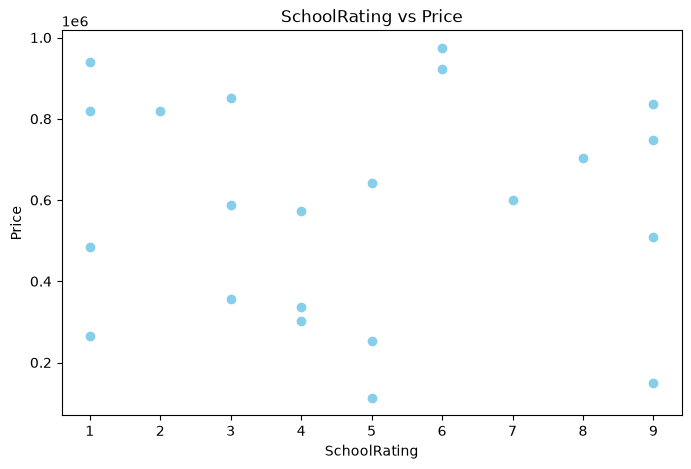

In [67]:
plt.figure(figsize=(8, 5))
plt.scatter(x=df['SchoolRating'], y=df['Price'], color='skyblue')
plt.title('SchoolRating vs Price')
plt.xlabel('SchoolRating')
plt.ylabel('Price')
plt.show()

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [58]:
X = df[['SchoolRating']]
y = df['Price']

In [59]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-2303.28]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['SchoolRating']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.66e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [60]:
print(model.coef_, model.intercept_)

[-2303.2816568] 466005.75029585796


In [61]:
y_pred = model.predict(X)
y_pred

array([461399.18698225, 452186.06035503, 447579.49704142, 452186.06035503,
       447579.49704142, 445276.21538462, 456792.62366864, 452186.06035503,
       459095.90532544, 452186.06035503, 445276.21538462, 447579.49704142,
       454489.34201183, 449882.77869822])

In [62]:
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f'MSE : {mse}')
print(f'MAE : {mae}')

MSE : 46431019471.658
MAE : 181927.89940828402


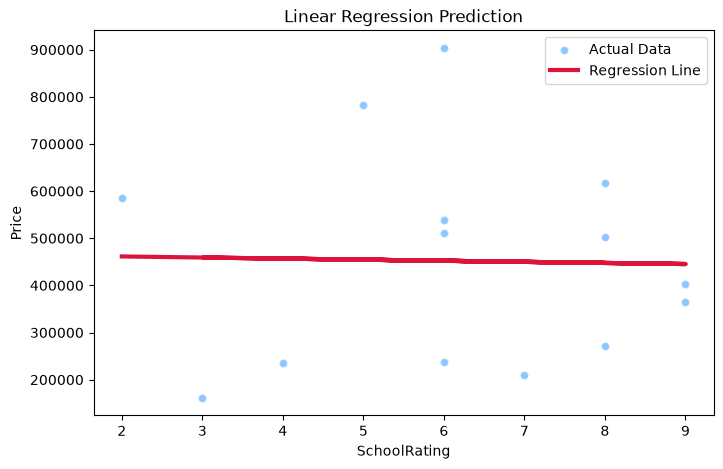

In [63]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.5, edgecolor='w', label='Actual Data')
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Regression Line')
plt.title('Linear Regression Prediction')
plt.xlabel('SchoolRating')
plt.ylabel('Price')
plt.legend()
plt.show()